In [1]:
from os import rename

import numpy as np
from datetime import datetime
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt

In [2]:
# SOFR
file_path = '../data/raw/SOFR.xlsx'
xls = pd.ExcelFile(file_path)

# read all sheets into dict
dfs = {sheet: pd.read_excel(file_path, sheet_name=sheet)
       for sheet in xls.sheet_names}

dfs

{'TSFR1M Index':            Date  TSFR1M Index
 0    2026-03-30           NaN
 1    2026-03-26       3.67306
 2    2026-03-25       3.67636
 3    2026-03-24       3.68065
 4    2026-03-23       3.67855
 ...         ...           ...
 1243 2021-04-06       0.01489
 1244 2021-04-05       0.01399
 1245 2021-04-02       0.01399
 1246 2021-04-01       0.01407
 1247 2021-03-31       0.01679
 
 [1248 rows x 2 columns],
 'TSFR3M Index':            Date  TSFR3M Index
 0    2026-03-30           NaN
 1    2026-03-26       3.70074
 2    2026-03-25       3.71082
 3    2026-03-24       3.71088
 4    2026-03-23       3.71601
 ...         ...           ...
 1243 2021-04-06       0.01996
 1244 2021-04-05       0.01958
 1245 2021-04-02       0.01958
 1246 2021-04-01       0.01910
 1247 2021-03-31       0.02184
 
 [1248 rows x 2 columns],
 'TSFR6M Index':            Date  TSFR6M Index
 0    2026-03-30           NaN
 1    2026-03-26       3.73371
 2    2026-03-25       3.74886
 3    2026-03-24       3.739

In [3]:
rename_map = {
    "TSFR1M Index": "1M",
    "TSFR3M Index": "3M",
    "TSFR6M Index": "6M",
    "TSFR12M Index": "12M"
}

for sheet, df in dfs.items():
    dfs[sheet] = df.rename(columns={
        sheet: rename_map[sheet]
    })


In [4]:
SOFR_df = None

for df in dfs.values():
    if SOFR_df is None:
        SOFR_df = df
    else:
        SOFR_df = pd.merge(SOFR_df, df, on="Date", how="inner")
SOFR_df

,Date,1M,3M,6M,12M
0,2026-03-30,NaN,NaN,NaN,NaN
1,2026-03-26,3.67306,3.70074,3.73371,3.78879
2,2026-03-25,3.67636,3.71082,3.74886,3.81141
3,2026-03-24,3.68065,3.71088,3.73996,3.78131
4,2026-03-23,3.67855,3.71601,3.75173,3.82105
...,...,...,...,...,...
1122,2021-09-27,0.05687,0.05831,0.05665,0.06891
1123,2021-09-24,0.05593,0.05788,0.05578,0.06540
1124,2021-09-23,0.05421,0.05688,0.05491,0.06083
1125,2021-09-22,0.05678,0.05795,0.05544,0.05954


In [5]:
SOFR_df['Date'] = pd.to_datetime(SOFR_df['Date'])
SOFR_df = SOFR_df.set_index('Date')
SOFR_df = SOFR_df.sort_index()
SOFR_df = SOFR_df.dropna(how='all')

In [6]:
SOFR_df = SOFR_df / 100

In [7]:
SOFR_df.tail()

,1M,3M,6M,12M
Date,,,,
2026-03-20,0.036779,0.037062,0.037281,0.037564
2026-03-23,0.036785,0.037160,0.037517,0.038211
2026-03-24,0.036806,0.037109,0.037400,0.037813
2026-03-25,0.036764,0.037108,0.037489,0.038114
2026-03-26,0.036731,0.037007,0.037337,0.037888


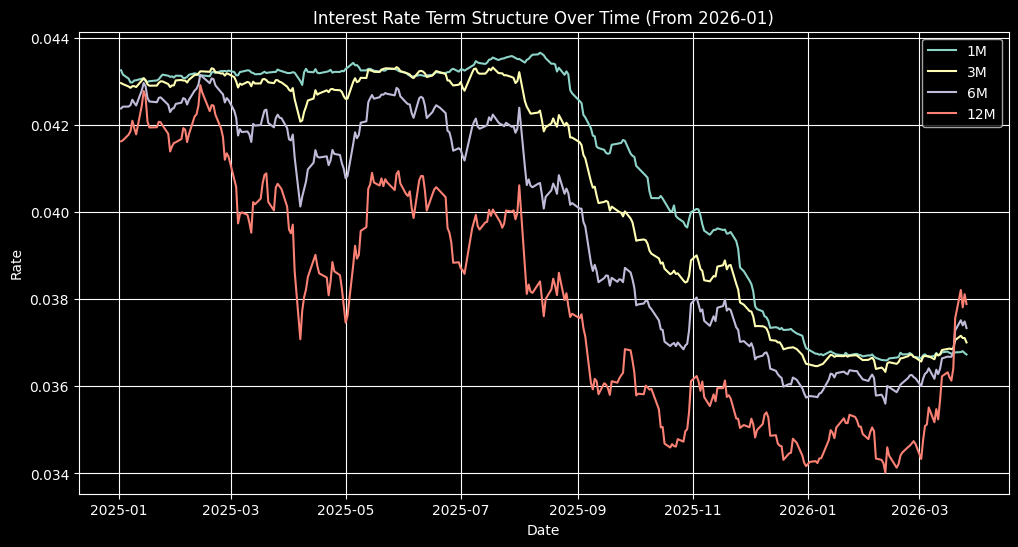

In [8]:
df_plot = SOFR_df.loc['2025-01-01':]

plt.figure(figsize=(12,6))

tenors = ['1M', '3M', '6M', '12M']

for tenor in tenors:
    plt.plot(df_plot.index, df_plot[tenor], label=tenor)

plt.title('Interest Rate Term Structure Over Time (From 2026-01)')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.legend()
plt.grid(True)

plt.show()

yield is inverted until mid-march

In [9]:
# SOFR_df.to_parquet("../data/processed/SOFR.parquet")
SOFR_df.to_excel("../data/processed/SOFR.xlsx")

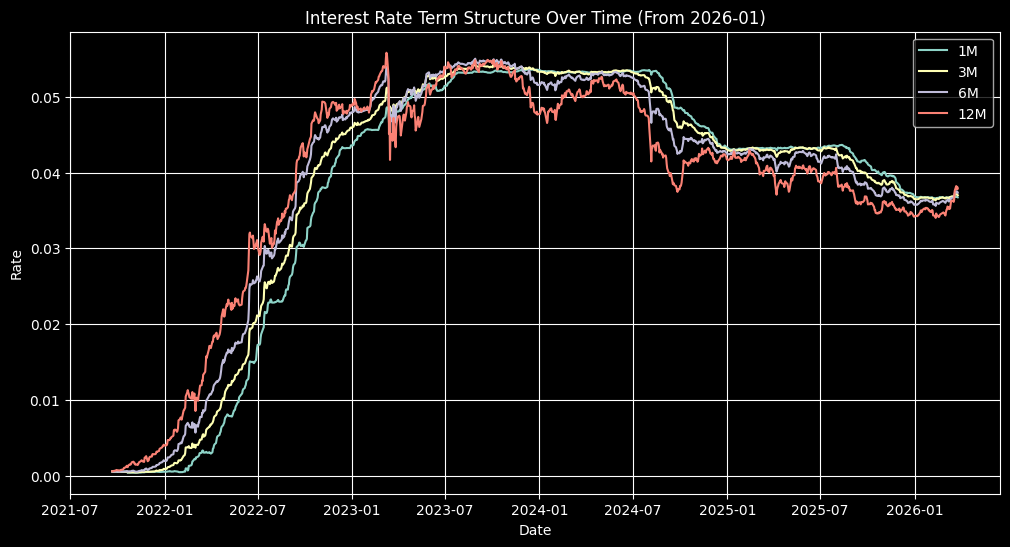

In [11]:
df_plot = SOFR_df

plt.figure(figsize=(12,6))

tenors = ['1M', '3M', '6M', '12M']

for tenor in tenors:
    plt.plot(df_plot.index, df_plot[tenor], label=tenor)

plt.title('Interest Rate Term Structure Over Time (From 2026-01)')
plt.xlabel('Date')
plt.ylabel('Rate')
plt.legend()
plt.grid(True)

plt.show()